In [7]:
from customCTF import *
%matplotlib inline

def draw_graph(G, pos=None, fig=None, ax=None, node_pose_dict=None, label_fontsize=5):
    if fig is None and ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    plt.xlim(-3, 13)
    plt.ylim(-13, 3)

    pos_dict = nx.get_node_attributes(G, 'pos')
    nx.draw(G, pos=pos_dict, ax=ax, node_size=20, edge_color='black', node_color='#333333', width=1)


    if node_pose_dict is not None and label_fontsize is not None:
        for node, coord in node_pose_dict.items():
            if node in pos_dict:
                x, y = pos_dict[node]
                x, y = np.round(x), np.round(y) 
                ax.annotate(
                    f"{coord}",
                    xy=(x, y),
                    xytext=(x + 0.15, y + 0.15),
                    fontsize=label_fontsize,
                    color='steelblue',
                    ha='left',
                    va='bottom',
                    zorder=7,
                )

    return fig, ax

In [8]:
def draw_graph(G, pos=None, fig=None, ax=None, node_pose_dict=None, label_fontsize=5):
    if fig is None and ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    node_pose_dict = nx.get_node_attributes(G, 'pos')
    nx.draw(G, pos=node_pose_dict, ax=ax, node_size=20, edge_color='black', node_color='#333333', width=1)

    if node_pose_dict is not None and label_fontsize is not None:
        for node, coord in node_pose_dict.items():
            if node in node_pose_dict:
                x, y = node_pose_dict[node]
                x, y = np.round(x), np.round(y)
                ax.annotate(
                    f"{coord}",
                    xy=(x, y),
                    xytext=(x + 0.15, y + 0.15),
                    fontsize=label_fontsize,
                    color='steelblue',
                    ha='left',
                    va='bottom',
                    zorder=7,
                )

    return fig, ax

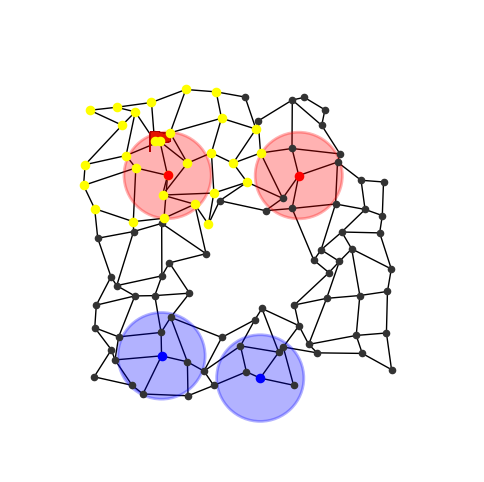

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [11]:
graphctf = GraphCTF(fixed_flag_hypothesis=1)
bc = graphctf.make_basin_corridor_medium(seed=2, nx_dim=11, ny_dim=11, rho = 0.86,
                ell = 3.2)
pos_dict = nx.get_node_attributes(bc.G, 'pos')

G = bc.G #graphctf.graph
red_flag_node = bc.red_flag_L
red_flag_2_node = bc.red_flag_R
blue_flag_node = graphctf.blue_flag_node
graphctf.reset()
graphctf.render()

In [ ]:
for node in G.nodes:
    print("node: {}, pos: {}".format(node, pos_dict[node]))

## Red flag location: red_flag_r from graphctf environment. (Remember: today in the Highbay the Red flag was on the right side not left).

node: 0, pos: [ 0.06616868 -0.18296195]
node: 1, pos: [ 0.85542776 -0.85451358]
node: 2, pos: [2.62989758 0.40045806]
node: 3, pos: [2.88610201 0.27083231]
node: 4, pos: [ 4.09842373 -0.19383799]
node: 6, pos: [ 5.88491163 -0.27725136]
node: 7, pos: [ 7.15923532 -0.03471932]
node: 8, pos: [ 8.19085105 -0.21251499]
node: 9, pos: [ 9.04438975 -0.31229592]
node: 10, pos: [10.29451274  0.06581228]
node: 11, pos: [ 0.11569985 -0.85632363]
node: 12, pos: [ 0.64623487 -0.72588665]
node: 13, pos: [ 2.71984599 -1.57345488]
node: 14, pos: [ 2.39470599 -1.52669099]
node: 15, pos: [ 4.29451061 -0.95494952]
node: 16, pos: [ 5.37741985 -0.74714919]
node: 17, pos: [ 6.07370013 -0.90058665]
node: 18, pos: [ 6.94058383 -0.69603893]
node: 19, pos: [ 7.60459941 -1.14765059]
node: 20, pos: [ 9.0850286 -0.3695027]
node: 21, pos: [ 9.73243756 -1.37767116]
node: 22, pos: [-0.19715052 -1.66075473]
node: 23, pos: [ 0.91774807 -1.53647854]
node: 24, pos: [ 1.34461467 -1.6050169 ]
node: 25, pos: [ 3.36220318 -2.

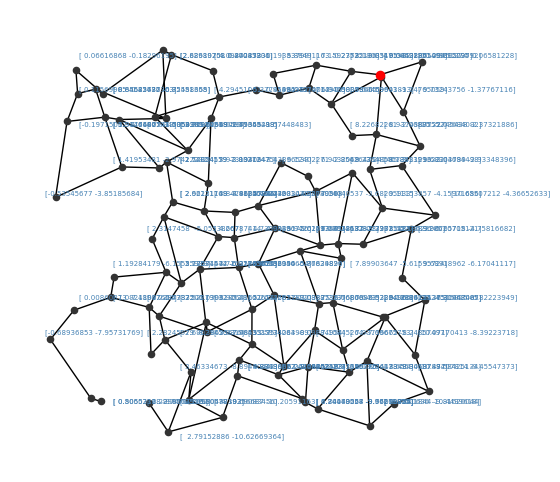

In [ ]:
fig, ax = draw_graph(bc.G)
pos = pos_dict[red_flag_2_node]
ax.scatter(*pos, color="red", s=35, zorder=6)
plt.show()

In [ ]:
G.number_of_nodes()

104

In [ ]:
def scatter_nodes(nodes, map_pos, color, label, size=30):
    if nodes:
        xs = [map_pos[n][0] for n in nodes]
        ys = [map_pos[n][1] for n in nodes]
        ax.scatter(xs, ys, color=color, s=size, zorder=5, label=label)

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
seed   = 30597 #30585 for nx_dim=14 and choke rows 6,8 #30597 is FINAL for nx_dim=11 and 4,6 choke rows #30550 51 and 56, 58, 62 (58 and 62 are similar) and 63 is rectangular, 75, 97 is EPIC #112497 looks good and final #14021997 #1051951 #3051947 is GREAT #5031947 is GREAT (Daadi) #5011951 is GREAT (Naanu) #231 is good. #11162001 is perfect but top disconnected. #31071976 #222
nx_dim = 11     # total rows  (top + choke + bottom)
ny_dim = 11      # columns
rho    = 0.80    # fraction of open nodes
ell    = 3.2     # CRF correlation length
jitter = 0.35

choke_row_start = 4+1 #5                              # rows [start, end] form the wall
choke_row_end   = 6+1 #7
passage_cols    = {0, 1, 2, 3, ny_dim-4, ny_dim-3, ny_dim-2, ny_dim-1}    # columns kept open through the choke
funnel_rows     = 2    # rows above/below choke forced open on passage cols

rng = np.random.default_rng(seed)
N   = nx_dim * ny_dim

# ── Positions ─────────────────────────────────────────────────────────────────
pos = {}
for i in range(nx_dim):
    for j in range(ny_dim):
        u = i * ny_dim + j
        pos[u] = np.array([j + jitter * rng.normal(),
                            -i + jitter * rng.normal()], dtype=float)

# ── 4-connected grid edges ────────────────────────────────────────────────────
edges = []
for i in range(nx_dim):
    for j in range(ny_dim):
        u = i * ny_dim + j
        if i + 1 < nx_dim:
            edges.append((u, (i + 1) * ny_dim + j))
        if j + 1 < ny_dim:
            edges.append((u, i * ny_dim + (j + 1)))

# ── Correlated random field ───────────────────────────────────────────────────
coords = np.array([[i, j] for i in range(nx_dim) for j in range(ny_dim)], dtype=float)
D      = np.linalg.norm(coords[:, None] - coords[None], axis=2)
Sigma  = np.exp(-D / ell) + 1e-6 * np.eye(N)
L      = np.linalg.cholesky(Sigma)
z      = L @ rng.standard_normal(N)
tau    = np.quantile(z, 1 - rho)
open_nodes = {u for u in range(N) if z[u] >= tau}

# ── Choke mask ────────────────────────────────────────────────────────────────
# Force close the wall; force open passage cols inside choke
for i in range(choke_row_start, choke_row_end + 1):
    for j in range(ny_dim):
        u = i * ny_dim + j
        if j not in passage_cols:
            open_nodes.discard(u)
        else:
            open_nodes.add(u)

# Funnel: force passage cols open for `funnel_rows` rows above and below the choke
# so passages are guaranteed to reach into both regions regardless of CRF
for i in range(max(0, choke_row_start - funnel_rows), choke_row_start):
    for j in passage_cols:
        open_nodes.add(i * ny_dim + j)
for i in range(choke_row_end + 1, min(nx_dim, choke_row_end + 1 + funnel_rows)):
    for j in passage_cols:
        open_nodes.add(i * ny_dim + j)

# ── Build graph + largest CC ──────────────────────────────────────────────────
G = nx.Graph()
for u in open_nodes:
    G.add_node(u, pos=pos[u])
for u, v in edges:
    if u in open_nodes and v in open_nodes:
        G.add_edge(u, v)

largest_cc = max(nx.connected_components(G), key=len)
G_map = G.subgraph(largest_cc).copy()

print(f"Map: {G_map.number_of_nodes()} nodes, {G_map.number_of_edges()} edges")
print(f"Top region: {sum(1 for u in G_map if u//ny_dim < choke_row_start)} nodes")
print(f"Bottom region: {sum(1 for u in G_map if u//ny_dim > choke_row_end)} nodes")

Map: 102 nodes, 175 edges
Top region: 48 nodes
Bottom region: 30 nodes


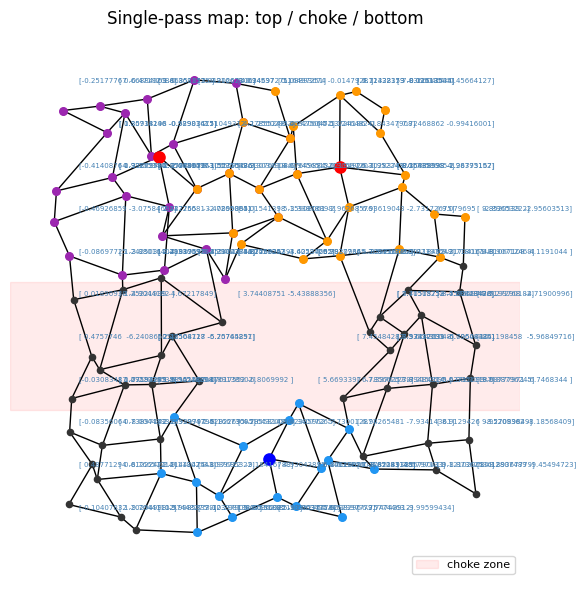

In [ ]:
fig, ax = draw_graph(G_map)
map_pos = nx.get_node_attributes(G_map, 'pos')

# Shade choke zone
ax.axhspan(-choke_row_end - 0.5, -choke_row_start + 0.5,
           alpha=0.08, color='red', zorder=0, label='choke zone')

# Highlight passage nodes
passage_nodes = [u for u in G_map.nodes()
                 if choke_row_start <= (u // ny_dim) <= choke_row_end]
view_passage_nodes = False
if passage_nodes and view_passage_nodes:
    ax.scatter([map_pos[n][0] for n in passage_nodes],
               [map_pos[n][1] for n in passage_nodes],
               color='orange', s=40, zorder=6, label='passages')

ax.legend(loc='lower right', fontsize=8)
ax.set_title('Single-pass map: top / choke / bottom')

rf1, rf2 = 24, 40 #35, 40
rf2 = 29 #29

pos = map_pos[rf1] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
visible_rf1_ = set(nx.single_source_shortest_path_length(G_map, rf1, cutoff=4).keys())
visible_rf1 = copy.deepcopy(visible_rf1_)
for node in visible_rf1_:
    if node in passage_nodes:
        visible_rf1.remove(node)
scatter_nodes(visible_rf1, map_pos, '#9C27B0', f'rf only (≤{4} hops)')

pos = map_pos[rf2] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
visible_rf2_ = set(nx.single_source_shortest_path_length(G_map, rf2, cutoff=4).keys())
visible_rf2 = copy.deepcopy(visible_rf2_)
for node in visible_rf2_:
    if node in passage_nodes:
        visible_rf2.remove(node)
scatter_nodes(visible_rf2, map_pos, '#FF9800', f'rf only (≤{4} hops)')

bf = 104 #104
pos = map_pos[bf] #np.array([5, -7]) 
ax.scatter(*pos, color="blue", s=65, zorder=6) #s=35

reach_bf = set(nx.single_source_shortest_path_length(G_map, bf, cutoff=3).keys())
scatter_nodes(reach_bf, map_pos, '#2196F3', f'bf only (≤{2} hops)')

plt.tight_layout()
plt.show()

In [ ]:
graphctf

In [ ]:
G.number_of_nodes()

102

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
seed   = 30597 #30585 for nx_dim=14 and choke rows 6,8 #30597 is FINAL for nx_dim=11 and 4,6 choke rows #30550 51 and 56, 58, 62 (58 and 62 are similar) and 63 is rectangular, 75, 97 is EPIC #112497 looks good and final #14021997 #1051951 #3051947 is GREAT #5031947 is GREAT (Daadi) #5011951 is GREAT (Naanu) #231 is good. #11162001 is perfect but top disconnected. #31071976 #222
nx_dim = 11     # total rows  (top + choke + bottom)
ny_dim = 11      # columns
rho    = 0.80    # fraction of open nodes
ell    = 3.2     # CRF correlation length
jitter = 0.35

choke_row_start = 4+1 #5                              # rows [start, end] form the wall
choke_row_end   = 6+1 #7
passage_cols    = {0, 1, 2, ny_dim-3, ny_dim-2, ny_dim-1}    # columns kept open through the choke
funnel_rows     = 2    # rows above/below choke forced open on passage cols

rng = np.random.default_rng(seed)
N   = nx_dim * ny_dim

# ── Positions ─────────────────────────────────────────────────────────────────
pos = {}
for i in range(nx_dim):
    for j in range(ny_dim):
        u = i * ny_dim + j
        pos[u] = np.array([j + jitter * rng.normal(),
                            -i + jitter * rng.normal()], dtype=float)

# ── 4-connected grid edges ────────────────────────────────────────────────────
edges = []
for i in range(nx_dim):
    for j in range(ny_dim):
        u = i * ny_dim + j
        if i + 1 < nx_dim:
            edges.append((u, (i + 1) * ny_dim + j))
        if j + 1 < ny_dim:
            edges.append((u, i * ny_dim + (j + 1)))

# ── Correlated random field ───────────────────────────────────────────────────
coords = np.array([[i, j] for i in range(nx_dim) for j in range(ny_dim)], dtype=float)
D      = np.linalg.norm(coords[:, None] - coords[None], axis=2)
Sigma  = np.exp(-D / ell) + 1e-6 * np.eye(N)
L      = np.linalg.cholesky(Sigma)
z      = L @ rng.standard_normal(N)
tau    = np.quantile(z, 1 - rho)
open_nodes = {u for u in range(N) if z[u] >= tau}

# ── Choke mask ────────────────────────────────────────────────────────────────
# Force close the wall; force open passage cols inside choke
for i in range(choke_row_start, choke_row_end + 1):
    for j in range(ny_dim):
        u = i * ny_dim + j
        if j not in passage_cols:
            open_nodes.discard(u)
        else:
            open_nodes.add(u)

# Funnel: force passage cols open for `funnel_rows` rows above and below the choke
# so passages are guaranteed to reach into both regions regardless of CRF
for i in range(max(0, choke_row_start - funnel_rows), choke_row_start):
    for j in passage_cols:
        open_nodes.add(i * ny_dim + j)
for i in range(choke_row_end + 1, min(nx_dim, choke_row_end + 1 + funnel_rows)):
    for j in passage_cols:
        open_nodes.add(i * ny_dim + j)

# ── Build graph + largest CC ──────────────────────────────────────────────────
G = nx.Graph()
for u in open_nodes:
    G.add_node(u, pos=pos[u])
for u, v in edges:
    if u in open_nodes and v in open_nodes:
        G.add_edge(u, v)

largest_cc = max(nx.connected_components(G), key=len)
G_map = G.subgraph(largest_cc).copy()

print(f"Map: {G_map.number_of_nodes()} nodes, {G_map.number_of_edges()} edges")
print(f"Top region: {sum(1 for u in G_map if u//ny_dim < choke_row_start)} nodes")
print(f"Bottom region: {sum(1 for u in G_map if u//ny_dim > choke_row_end)} nodes")

Map: 96 nodes, 161 edges
Top region: 48 nodes
Bottom region: 30 nodes


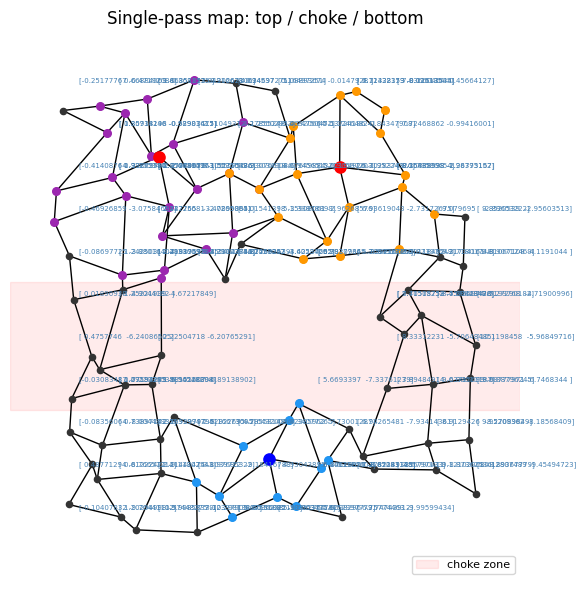

In [ ]:
fig, ax = draw_graph(G_map)
map_pos = nx.get_node_attributes(G_map, 'pos')

# Shade choke zone
ax.axhspan(-choke_row_end - 0.5, -choke_row_start + 0.5,
           alpha=0.08, color='red', zorder=0, label='choke zone')

# Highlight passage nodes
passage_nodes = [u for u in G_map.nodes()
                 if choke_row_start <= (u // ny_dim) <= choke_row_end]
view_passage_nodes = False
if passage_nodes and view_passage_nodes:
    ax.scatter([map_pos[n][0] for n in passage_nodes],
               [map_pos[n][1] for n in passage_nodes],
               color='orange', s=40, zorder=6, label='passages')

ax.legend(loc='lower right', fontsize=8)
ax.set_title('Single-pass map: top / choke / bottom')

rf1, rf2 = 24, 24 #35, 40
rf2 = 29 #29

pos = map_pos[rf1] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
visible_rf1 = set(nx.single_source_shortest_path_length(G_map, rf1, cutoff=3).keys())
scatter_nodes(visible_rf1, map_pos, '#9C27B0', f'rf only (≤{3} hops)')

pos = map_pos[rf2] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
visible_rf2 = set(nx.single_source_shortest_path_length(G_map, rf2, cutoff=3).keys())
scatter_nodes(visible_rf2, map_pos, '#FF9800', f'rf only (≤{3} hops)')

bf = 104 #104
pos = map_pos[bf] #np.array([5, -7]) 
ax.scatter(*pos, color="blue", s=65, zorder=6) #s=35

reach_bf = set(nx.single_source_shortest_path_length(G_map, bf, cutoff=2).keys())
scatter_nodes(reach_bf, map_pos, '#2196F3', f'bf only (≤{2} hops)')

plt.tight_layout()
plt.show()

In [ ]:
list(nx.single_source_shortest_path_length(G_map, bf, cutoff=2).keys())

[104, 93, 103, 115, 105, 92, 94, 102, 114, 116, 106]

In [ ]:
map_pos[rf1]

array([ 2.15984035, -1.55316386])

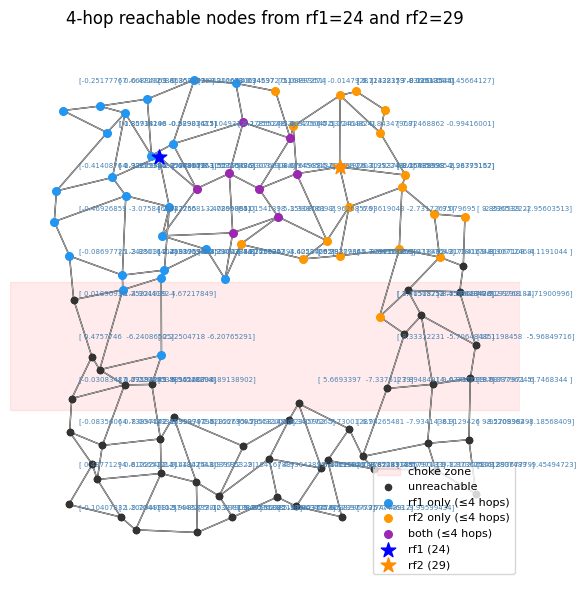

rf1 reach: 32  rf2 reach: 27  overlap: 8


In [ ]:

# 5-hop reachable nodes from rf1 and rf2
K = 4 #3 # TIME HORIZON = 35 is good to see strategies emerge. # Commitment before info is a probe, what others?
reach1 = set(nx.single_source_shortest_path_length(G_map, rf1, cutoff=K).keys())
reach2 = set(nx.single_source_shortest_path_length(G_map, rf2, cutoff=K).keys())
both   = reach1 & reach2
only1  = reach1 - reach2
only2  = reach2 - reach1
neither = set(G_map.nodes()) - reach1 - reach2

#fig, ax = plt.subplots(figsize=(7, 7))
fig, ax = draw_graph(G_map)

# Shade choke zone
ax.axhspan(-choke_row_end - 0.5, -choke_row_start + 0.5,
           alpha=0.08, color='red', zorder=0, label='choke zone')

nx.draw_networkx_edges(G_map, pos=map_pos, ax=ax, edge_color='#aaaaaa', width=0.8)

scatter_nodes(neither, map_pos, '#333333', 'unreachable', size=20)
scatter_nodes(only1, map_pos,   '#2196F3', f'rf1 only (≤{K} hops)')
scatter_nodes(only2, map_pos,   '#FF9800', f'rf2 only (≤{K} hops)')
scatter_nodes(both, map_pos, '#9C27B0', f'both (≤{K} hops)')

# Flag nodes
ax.scatter(*map_pos[rf1], color='blue',   s=120, zorder=8, marker='*', label=f'rf1 ({rf1})')
ax.scatter(*map_pos[rf2], color='darkorange', s=120, zorder=8, marker='*', label=f'rf2 ({rf2})')

ax.legend(loc='lower right', fontsize=8)
ax.set_title(f'{K}-hop reachable nodes from rf1={rf1} and rf2={rf2}')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"rf1 reach: {len(reach1)}  rf2 reach: {len(reach2)}  overlap: {len(both)}")

# Blue init zone: x \in [3, 8] and y \in [9, 10]
# Red init zone: 5-hop visibility regions of the flags, and not in the overlap of the 5-hop regions of the two hypothesis.
# Visibility region: 3-hop.

### Generate top basin and bottom basin for this basin_corridoor graph. Use that to generate corridoor nodes and patrol nodes.
### Bottom Basin: x \in [3, 8] and y \in [9, 10].


### Red respawn: respawn if tagged in choke or bottom region -- init respawn.
### Red respawn: if tagged near flag, respawn in the other red flag basin.

# MAPS FOR HIGHBAY GRAPH CTF

In [ ]:
def update_pos(pos):
    # x_new \in [0, 10]
    # y_new \in [-10, 0]
    import numpy as np
    assert isinstance(pos, np.ndarray)
    x, y = pos

    x_new = 0 + 10.*(x-x_min)/(x_max - x_min)
    y_new = -10 + 10.*(y-y_min)/(y_max - y_min)
    return np.array([x_new, y_new])

Map: 36 nodes, 60 edges
Top region: 12 nodes
Bottom region: 12 nodes


/tmp/ipykernel_1895898/1405852589.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', fontsize=8)


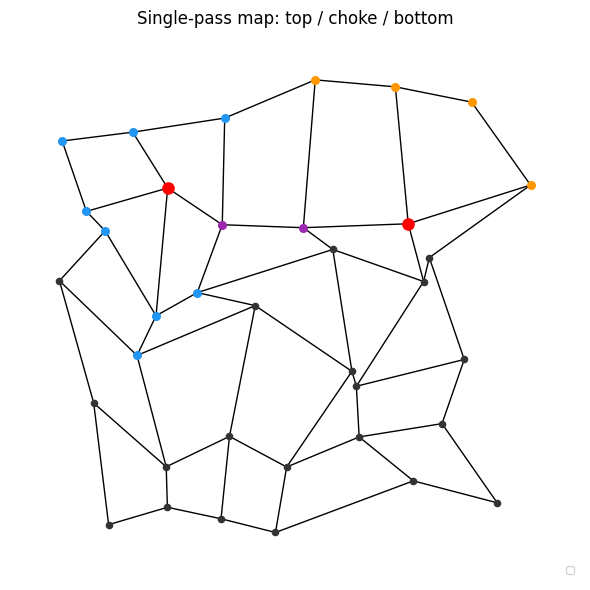

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
seed   = 30597 #30597 #30585 for nx_dim=14 and choke rows 6,8 #30597 is FINAL for nx_dim=11 and 4,6 choke rows #30550 51 and 56, 58, 62 (58 and 62 are similar) and 63 is rectangular, 75, 97 is EPIC #112497 looks good and final #14021997 #1051951 #3051947 is GREAT #5031947 is GREAT (Daadi) #5011951 is GREAT (Naanu) #231 is good. #11162001 is perfect but top disconnected. #31071976 #222
nx_dim = 6 #11     # total rows  (top + choke + bottom)
ny_dim = 6 #11      # columns
rho    = 0.80    # fraction of open nodes
ell    = 3.2     # CRF correlation length
jitter = 0.35

choke_row_start = 2 #4+1 #5                              # rows [start, end] form the wall
choke_row_end   = 4-1 #6+1 #7
passage_cols    = {0, 1, 2, ny_dim-3, ny_dim-2, ny_dim-1} #{0, 1, 2, 3, ny_dim-4, ny_dim-3, ny_dim-2, ny_dim-1}    # columns kept open through the choke
funnel_rows     = 2 #2    # rows above/below choke forced open on passage cols

rng = np.random.default_rng(seed)
N   = nx_dim * ny_dim

# ── Positions ─────────────────────────────────────────────────────────────────
pos = {}
for i in range(nx_dim):
    for j in range(ny_dim):
        u = i * ny_dim + j
        pos[u] = np.array([j + jitter * rng.normal(),
                            -i + jitter * rng.normal()], dtype=float)

# ── 4-connected grid edges ────────────────────────────────────────────────────
edges = []
for i in range(nx_dim):
    for j in range(ny_dim):
        u = i * ny_dim + j
        if i + 1 < nx_dim:
            edges.append((u, (i + 1) * ny_dim + j))
        if j + 1 < ny_dim:
            edges.append((u, i * ny_dim + (j + 1)))

# ── Correlated random field ───────────────────────────────────────────────────
coords = np.array([[i, j] for i in range(nx_dim) for j in range(ny_dim)], dtype=float)
D      = np.linalg.norm(coords[:, None] - coords[None], axis=2)
Sigma  = np.exp(-D / ell) + 1e-6 * np.eye(N)
L      = np.linalg.cholesky(Sigma)
z      = L @ rng.standard_normal(N)
tau    = np.quantile(z, 1 - rho)
open_nodes = {u for u in range(N) if z[u] >= tau}

# ── Choke mask ────────────────────────────────────────────────────────────────
# Force close the wall; force open passage cols inside choke
for i in range(choke_row_start, choke_row_end + 1):
    for j in range(ny_dim):
        u = i * ny_dim + j
        if j not in passage_cols:
            open_nodes.discard(u)
        else:
            open_nodes.add(u)

# Funnel: force passage cols open for `funnel_rows` rows above and below the choke
# so passages are guaranteed to reach into both regions regardless of CRF
for i in range(max(0, choke_row_start - funnel_rows), choke_row_start):
    for j in passage_cols:
        open_nodes.add(i * ny_dim + j)
for i in range(choke_row_end + 1, min(nx_dim, choke_row_end + 1 + funnel_rows)):
    for j in passage_cols:
        open_nodes.add(i * ny_dim + j)

# ── Build graph + largest CC ──────────────────────────────────────────────────
G = nx.Graph()
for u in open_nodes:
    G.add_node(u, pos=pos[u])
for u, v in edges:
    if u in open_nodes and v in open_nodes:
        G.add_edge(u, v)

largest_cc = max(nx.connected_components(G), key=len)
G_map = G.subgraph(largest_cc).copy()

print(f"Map: {G_map.number_of_nodes()} nodes, {G_map.number_of_edges()} edges")
print(f"Top region: {sum(1 for u in G_map if u//ny_dim < choke_row_start)} nodes")
print(f"Bottom region: {sum(1 for u in G_map if u//ny_dim > choke_row_end)} nodes")

fig, ax = draw_graph(G_map, label_fontsize=None) #draw_graph(G_map, label_fontsize=8)
map_pos = nx.get_node_attributes(G_map, 'pos')

"""
# Shade choke zone
ax.axhspan(-choke_row_end - 0.5, -choke_row_start + 0.5,
           alpha=0.08, color='red', zorder=0, label='choke zone')
"""

# Highlight passage nodes
passage_nodes = [u for u in G_map.nodes()
                 if choke_row_start <= (u // ny_dim) <= choke_row_end]
view_passage_nodes = False
if passage_nodes and view_passage_nodes:
    ax.scatter([map_pos[n][0] for n in passage_nodes],
               [map_pos[n][1] for n in passage_nodes],
               color='orange', s=40, zorder=6, label='passages')

ax.legend(loc='lower right', fontsize=8)
ax.set_title('Single-pass map: top / choke / bottom')

rf1, rf2 = 7, 10
K = 2
visible_rf1_ = set(nx.single_source_shortest_path_length(G_map, rf1, cutoff=K).keys())
visible_rf1 = copy.deepcopy(visible_rf1_)
"""
for node in visible_rf1_:
    if node in passage_nodes:
        visible_rf1.remove(node)
"""
visible_rf2_ = set(nx.single_source_shortest_path_length(G_map, rf2, cutoff=K).keys())
visible_rf2 = copy.deepcopy(visible_rf2_)
for node in visible_rf2_:
    if node in passage_nodes:
        visible_rf2.remove(node)

both   = visible_rf1 & visible_rf2
only1  = visible_rf1 - visible_rf2
only2  = visible_rf2 - visible_rf1
neither = set(G_map.nodes()) - visible_rf1 - visible_rf2

pos = map_pos[rf1] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
pos = map_pos[rf2] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35

scatter_nodes(only1, map_pos,   '#2196F3', f'rf1 only (≤{K} hops)')
scatter_nodes(only2, map_pos,   '#FF9800', f'rf2 only (≤{K} hops)')
scatter_nodes(both, map_pos, '#9C27B0', f'both (≤{K} hops)')

plt.tight_layout()
plt.show()

In [ ]:
G_map = G.subgraph(largest_cc).copy()
map_pos = nx.get_node_attributes(G_map, 'pos')
x_min, x_max = +np.inf, -np.inf
y_min, y_max = +np.inf, -np.inf

x_min_highbay = 0
x_max_highbay = 10

y_min_highbay = -10
y_max_highbay = 0

for node_idx, node_pos in map_pos.items():
    print("node_idx: {}, node_pos: {}".format(node_idx, node_pos))
    x_node, y_node = node_pos

    x_min = min(x_min, x_node)
    x_max = max(x_max, x_node)

    y_min = min(y_min, y_node)
    y_max = max(y_max, y_node)
print("x_min: {}, x_max: {}".format(x_min, x_max))
print("y_min: {}, y_max: {}".format(y_min, y_max))

node_idx: 0, node_pos: [-0.25177767 -0.47192086]
node_idx: 1, node_pos: [ 0.66884069 -0.3681575 ]
node_idx: 2, node_pos: [ 1.86851823 -0.20262106]
node_idx: 3, node_pos: [3.04916678 0.24697271]
node_idx: 4, node_pos: [4.094537   0.16497251]
node_idx: 5, node_pos: [ 5.08893674 -0.0147928 ]
node_idx: 6, node_pos: [ 0.06478643 -1.29991125]
node_idx: 7, node_pos: [ 1.12432179 -1.02513545]
node_idx: 8, node_pos: [ 1.83660464 -1.45664127]
node_idx: 9, node_pos: [ 2.8942605  -1.49163428]
node_idx: 10, node_pos: [ 4.26234748 -1.44541697]
node_idx: 11, node_pos: [ 5.85734246 -0.98981617]
node_idx: 12, node_pos: [ 0.30918198 -1.52903475]
node_idx: 13, node_pos: [ 0.97279672 -2.52755476]
node_idx: 14, node_pos: [ 1.51049312 -2.25502933]
node_idx: 15, node_pos: [ 3.27855248 -1.74750471]
node_idx: 16, node_pos: [ 4.46320664 -2.12464824]
node_idx: 17, node_pos: [ 4.53724186 -1.84347908]
node_idx: 18, node_pos: [-0.28671647 -2.11613534]
node_idx: 19, node_pos: [ 0.72468862 -2.99416001]
node_idx: 20, 

In [ ]:
def update_pos(pos):
    # x_new \in [0, 10]
    # y_new \in [-10, 0]
    import numpy as np
    assert isinstance(pos, np.ndarray)
    x, y = pos

    x_new = 0 + 10.*(x-x_min)/(x_max - x_min)
    y_new = -10 + 10.*(y-y_min)/(y_max - y_min)
    return np.array([x_new, y_new])

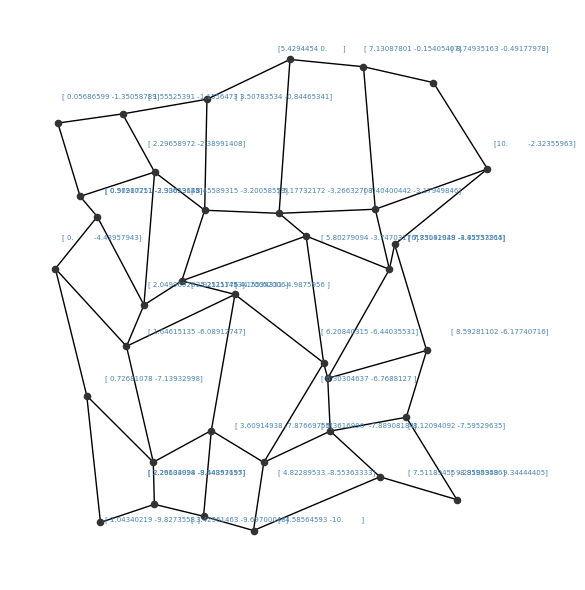

In [ ]:
pos_dict = nx.get_node_attributes(G_map, 'pos')
updated_pos = {node: {"pos": update_pos(pos_dict[node])} for node in G.nodes()}
nx.set_node_attributes(G_map, updated_pos)
draw_graph(G_map)

rf1, rf2 = 7, 10
K = 2
visible_rf1_ = set(nx.single_source_shortest_path_length(G_map, rf1, cutoff=K).keys())
visible_rf1 = copy.deepcopy(visible_rf1_)
"""
for node in visible_rf1_:
    if node in passage_nodes:
        visible_rf1.remove(node)
"""
visible_rf2_ = set(nx.single_source_shortest_path_length(G_map, rf2, cutoff=K).keys())
visible_rf2 = copy.deepcopy(visible_rf2_)
for node in visible_rf2_:
    if node in passage_nodes:
        visible_rf2.remove(node)

both   = visible_rf1 & visible_rf2
only1  = visible_rf1 - visible_rf2
only2  = visible_rf2 - visible_rf1
neither = set(G_map.nodes()) - visible_rf1 - visible_rf2

pos = map_pos[rf1] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
pos = map_pos[rf2] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35

scatter_nodes(only1, map_pos,   '#2196F3', f'rf1 only (≤{K} hops)')
scatter_nodes(only2, map_pos,   '#FF9800', f'rf2 only (≤{K} hops)')
scatter_nodes(both, map_pos, '#9C27B0', f'both (≤{K} hops)')

plt.tight_layout()
plt.show()

In [ ]:
nx.get_node_attributes(G_map, 'pos')

{0: array([ 0.05686599, -1.35058789]),
 1: array([ 1.55525391, -1.1556473 ]),
 2: array([ 3.50783534, -0.84465341]),
 3: array([5.4294454, 0.       ]),
 4: array([ 7.13087801, -0.15405407]),
 5: array([ 8.74935163, -0.49177978]),
 6: array([ 0.57210211, -2.90613635]),
 7: array([ 2.29658972, -2.38991408]),
 8: array([ 3.45589315, -3.20058559]),
 9: array([ 5.17732172, -3.26632708]),
 10: array([ 7.40400442, -3.17949846]),
 11: array([10.        , -2.32355963]),
 12: array([ 0.96987751, -3.33659148]),
 13: array([ 2.04996926, -5.21251453]),
 14: array([ 2.92511776, -4.70052006]),
 15: array([ 5.80279094, -3.74703176]),
 16: array([ 7.73092049, -4.45557264]),
 17: array([ 7.85141938, -3.92733915]),
 18: array([ 0.        , -4.43957943]),
 19: array([ 1.64615135, -6.08912747]),
 20: array([ 4.15594331, -4.9875956 ]),
 21: array([ 6.20840315, -6.44035531]),
 22: array([ 6.30304637, -6.7688127 ]),
 23: array([ 8.59281102, -6.17740716]),
 24: array([ 0.72681078, -7.13932998]),
 25: array([ 2

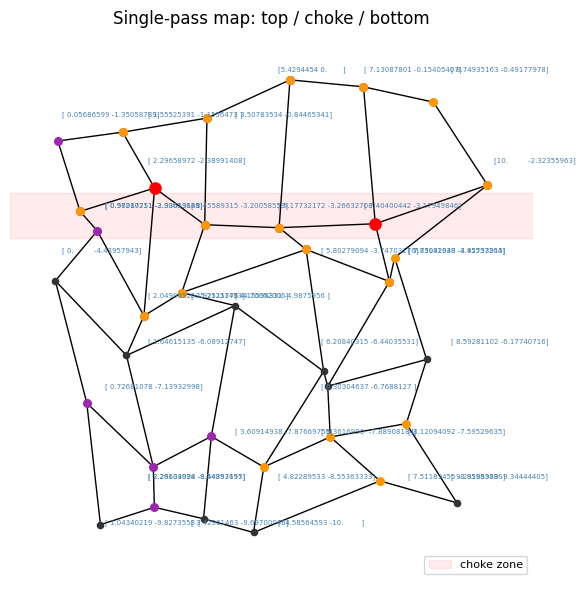

In [ ]:
fig, ax = draw_graph(G_map)
map_pos = nx.get_node_attributes(G_map, 'pos')

choke_row_start = 2+1 #4+1 #5                              # rows [start, end] form the wall
choke_row_end   = 4-1 #6+1 #7


# Shade choke zone
ax.axhspan(-choke_row_end - 0.5, -choke_row_start + 0.5,
           alpha=0.08, color='red', zorder=0, label='choke zone')

# Highlight passage nodes
passage_nodes = [u for u in G_map.nodes()
                 if choke_row_start <= (u // ny_dim) <= choke_row_end]
view_passage_nodes = False
if passage_nodes and view_passage_nodes:
    ax.scatter([map_pos[n][0] for n in passage_nodes],
               [map_pos[n][1] for n in passage_nodes],
               color='orange', s=40, zorder=6, label='passages')

ax.legend(loc='lower right', fontsize=8)
ax.set_title('Single-pass map: top / choke / bottom')

rf1 = 7 #24, 40 #35, 40
rf2 = 10 #29

pos = map_pos[rf1] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
visible_rf1_ = set(nx.single_source_shortest_path_length(G_map, rf1, cutoff=4).keys())
visible_rf1 = copy.deepcopy(visible_rf1_)
for node in visible_rf1_:
    if node in passage_nodes:
        visible_rf1.remove(node)
scatter_nodes(visible_rf1, map_pos, '#9C27B0', f'rf only (≤{4} hops)')

pos = map_pos[rf2] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
visible_rf2_ = set(nx.single_source_shortest_path_length(G_map, rf2, cutoff=4).keys())
visible_rf2 = copy.deepcopy(visible_rf2_)
for node in visible_rf2_:
    if node in passage_nodes:
        visible_rf2.remove(node)
scatter_nodes(visible_rf2, map_pos, '#FF9800', f'rf only (≤{4} hops)')

"""
bf = 0 #104 #104
pos = map_pos[bf] #np.array([5, -7]) 
ax.scatter(*pos, color="blue", s=65, zorder=6) #s=35
"""
#reach_bf = set(nx.single_source_shortest_path_length(G_map, bf, cutoff=3).keys())
#scatter_nodes(reach_bf, map_pos, '#2196F3', f'bf only (≤{2} hops)')

plt.tight_layout()
plt.show()

# THREE FLAG SCENARIO..

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
seed   = 30597 #30597 #30585 for nx_dim=14 and choke rows 6,8 #30597 is FINAL for nx_dim=11 and 4,6 choke rows #30550 51 and 56, 58, 62 (58 and 62 are similar) and 63 is rectangular, 75, 97 is EPIC #112497 looks good and final #14021997 #1051951 #3051947 is GREAT #5031947 is GREAT (Daadi) #5011951 is GREAT (Naanu) #231 is good. #11162001 is perfect but top disconnected. #31071976 #222
nx_dim = 11 #6 #11     # total rows  (top + choke + bottom)
ny_dim = 11 #6 #11      # columns
rho    = 0.80    # fraction of open nodes
ell    = 3.2     # CRF correlation length
jitter = 0.35

choke_row_start = 2 #4+1 #5                              # rows [start, end] form the wall
choke_row_end   = 4 #6+1 #7
passage_cols    = {0, 1, 2, ny_dim-3, ny_dim-2, ny_dim-1} #{0, 1, 2, 3, ny_dim-4, ny_dim-3, ny_dim-2, ny_dim-1}    # columns kept open through the choke
funnel_rows     = 2 #2    # rows above/below choke forced open on passage cols

rng = np.random.default_rng(seed)
N   = nx_dim * ny_dim

# ── Positions ─────────────────────────────────────────────────────────────────
pos = {}
for i in range(nx_dim):
    for j in range(ny_dim):
        u = i * ny_dim + j
        pos[u] = np.array([j + jitter * rng.normal(),
                            -i + jitter * rng.normal()], dtype=float)

# ── 4-connected grid edges ────────────────────────────────────────────────────
edges = []
for i in range(nx_dim):
    for j in range(ny_dim):
        u = i * ny_dim + j
        if i + 1 < nx_dim:
            edges.append((u, (i + 1) * ny_dim + j))
        if j + 1 < ny_dim:
            edges.append((u, i * ny_dim + (j + 1)))

# ── Correlated random field ───────────────────────────────────────────────────
coords = np.array([[i, j] for i in range(nx_dim) for j in range(ny_dim)], dtype=float)
D      = np.linalg.norm(coords[:, None] - coords[None], axis=2)
Sigma  = np.exp(-D / ell) + 1e-6 * np.eye(N)
L      = np.linalg.cholesky(Sigma)
z      = L @ rng.standard_normal(N)
tau    = np.quantile(z, 1 - rho)
open_nodes = {u for u in range(N) if z[u] >= tau}

# ── Choke mask ────────────────────────────────────────────────────────────────
# Force close the wall; force open passage cols inside choke
for i in range(choke_row_start, choke_row_end + 1):
    for j in range(ny_dim):
        u = i * ny_dim + j
        if j not in passage_cols:
            open_nodes.discard(u)
        else:
            open_nodes.add(u)

# Funnel: force passage cols open for `funnel_rows` rows above and below the choke
# so passages are guaranteed to reach into both regions regardless of CRF
for i in range(max(0, choke_row_start - funnel_rows), choke_row_start):
    for j in passage_cols:
        open_nodes.add(i * ny_dim + j)
for i in range(choke_row_end + 1, min(nx_dim, choke_row_end + 1 + funnel_rows)):
    for j in passage_cols:
        open_nodes.add(i * ny_dim + j)

# ── Build graph + largest CC ──────────────────────────────────────────────────
G = nx.Graph()
for u in open_nodes:
    G.add_node(u, pos=pos[u])
for u, v in edges:
    if u in open_nodes and v in open_nodes:
        G.add_edge(u, v)

largest_cc = max(nx.connected_components(G), key=len)
G_map = G.subgraph(largest_cc).copy()

print(f"Map: {G_map.number_of_nodes()} nodes, {G_map.number_of_edges()} edges")
print(f"Top region: {sum(1 for u in G_map if u//ny_dim < choke_row_start)} nodes")
print(f"Bottom region: {sum(1 for u in G_map if u//ny_dim > choke_row_end)} nodes")

Map: 96 nodes, 161 edges
Top region: 21 nodes
Bottom region: 57 nodes


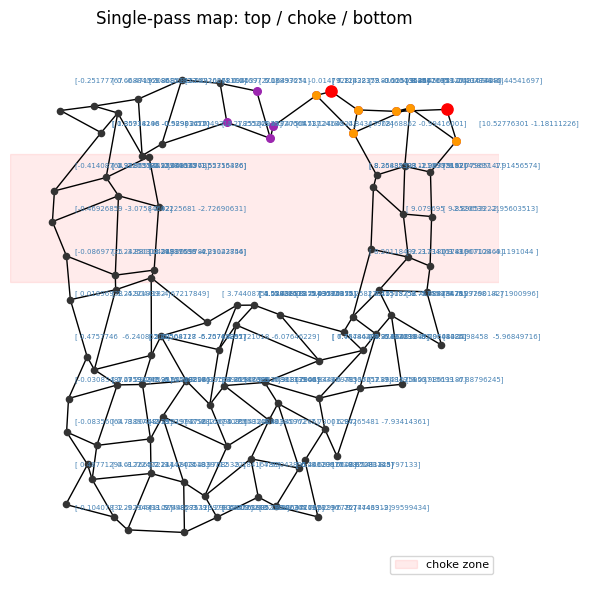

In [ ]:
fig, ax = draw_graph(G_map)
map_pos = nx.get_node_attributes(G_map, 'pos')

# Shade choke zone
ax.axhspan(-choke_row_end - 0.5, -choke_row_start + 0.5,
           alpha=0.08, color='red', zorder=0, label='choke zone')

# Highlight passage nodes
passage_nodes = [u for u in G_map.nodes()
                 if choke_row_start <= (u // ny_dim) <= choke_row_end]
view_passage_nodes = False
if passage_nodes and view_passage_nodes:
    ax.scatter([map_pos[n][0] for n in passage_nodes],
               [map_pos[n][1] for n in passage_nodes],
               color='orange', s=40, zorder=6, label='passages')

ax.legend(loc='lower right', fontsize=8)
ax.set_title('Single-pass map: top / choke / bottom')

rf1 = 7 #24, 40 #35, 40
rf2 = 10 #29

pos = map_pos[rf1] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
visible_rf1_ = set(nx.single_source_shortest_path_length(G_map, rf1, cutoff=4).keys())
visible_rf1 = copy.deepcopy(visible_rf1_)
for node in visible_rf1_:
    if node in passage_nodes:
        visible_rf1.remove(node)
scatter_nodes(visible_rf1, map_pos, '#9C27B0', f'rf only (≤{4} hops)')

pos = map_pos[rf2] #np.array([5, -7]) 
ax.scatter(*pos, color="red", s=65, zorder=6) #s=35
visible_rf2_ = set(nx.single_source_shortest_path_length(G_map, rf2, cutoff=4).keys())
visible_rf2 = copy.deepcopy(visible_rf2_)
for node in visible_rf2_:
    if node in passage_nodes:
        visible_rf2.remove(node)
scatter_nodes(visible_rf2, map_pos, '#FF9800', f'rf only (≤{4} hops)')

"""
bf = 0 #104 #104
pos = map_pos[bf] #np.array([5, -7]) 
ax.scatter(*pos, color="blue", s=65, zorder=6) #s=35

reach_bf = set(nx.single_source_shortest_path_length(G_map, bf, cutoff=3).keys())
scatter_nodes(reach_bf, map_pos, '#2196F3', f'bf only (≤{2} hops)')
"""
plt.tight_layout()
plt.show()

In [ ]:
from customCTF import *
from psro_v1 import *
from utils import *
from adjustText import adjust_text
%matplotlib inline

def draw_graph(G, pos=None, fig=None, ax=None, node_pose_dict=None, label_fontsize=5):
    if fig is None and ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    pos_dict = nx.get_node_attributes(G, 'pos')
    nx.draw(G, pos=pos_dict, ax=ax, node_size=20, edge_color='black', node_color='#333333', width=1)

    if node_pose_dict is not None and label_fontsize is not None:
        texts = []
        for node, coord in node_pose_dict.items():
            if node in pos_dict:
                x, y = pos_dict[node]
                t = ax.text(x, y, f"{coord}", fontsize=label_fontsize, color="steelblue", zorder=7)
                texts.append(t)
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4))

    return fig, ax

In [ ]:
import subprocess
subprocess.run(["pip", "install", "adjustText", "-q"], check=True)
print("installed")

installed


In [ ]:
from customCTF import *
from psro_v1 import *
from utils import *
from adjustText import adjust_text
%matplotlib inline

def draw_graph(G, pos=None, fig=None, ax=None, node_pose_dict=None, label_fontsize=5):
    if fig is None and ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    pos_dict = nx.get_node_attributes(G, 'pos')
    nx.draw(G, pos=pos_dict, ax=ax, node_size=20, edge_color='black', node_color='#333333', width=1)

    if node_pose_dict is not None and label_fontsize is not None:
        texts = []
        for node, coord in node_pose_dict.items():
            if node in pos_dict:
                x, y = pos_dict[node]
                t = ax.text(x, y, f"{coord}", fontsize=label_fontsize, color="steelblue", zorder=7)
                texts.append(t)
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4))

    return fig, ax

print("draw_graph defined")

draw_graph defined


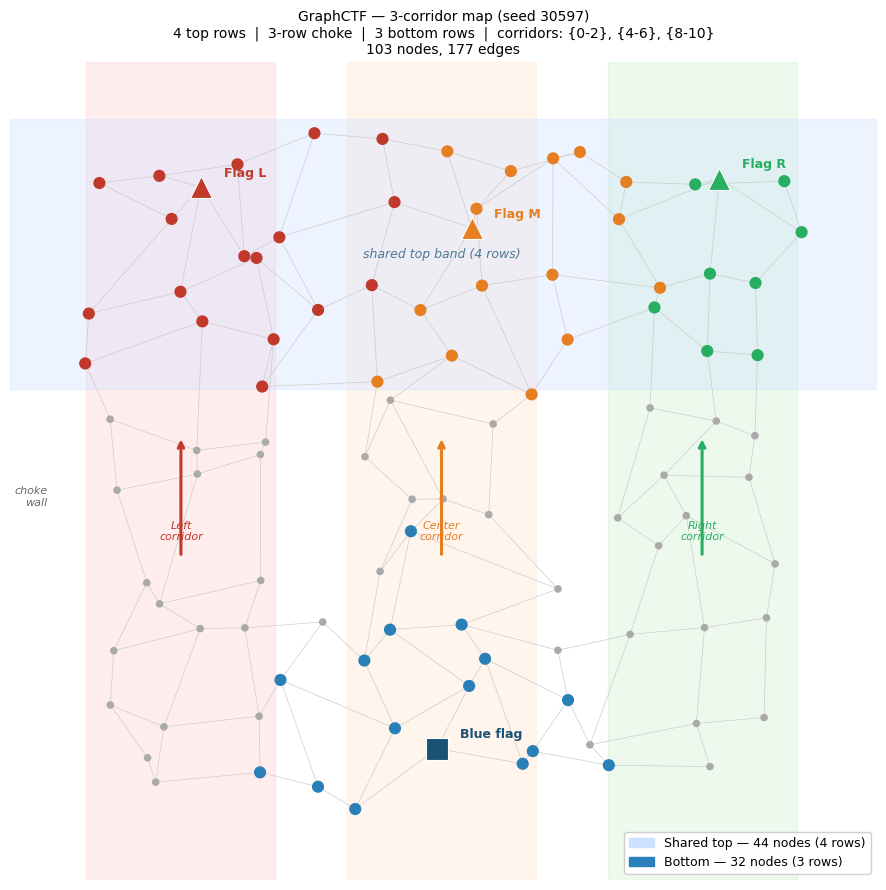

In [ ]:
# ── 3v2 Three-Flag Map ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

env_3v2 = GraphCTF(ctf_player_config="3v2")
env_3v2.reset()

bc   = env_3v2._bc
G3   = bc.G
pos3 = nx.get_node_attributes(G3, "pos")

# map geometry (mirrors make_3corridor_map defaults)
nx_dim, ny_dim   = 10, 11
choke_row_start  = 4          # first row of choke wall
choke_row_end    = 6          # last  row of choke wall
top_open_rows    = 4
jitter_pad       = 0.45       # display margin beyond ±jitter
left_cols        = {0, 1, 2}
center_cols      = {4, 5, 6}
right_cols       = {8, 9, 10}

# shading x-bounds per corridor
xL = (min(left_cols)   - jitter_pad, max(left_cols)   + jitter_pad)
xM = (min(center_cols) - jitter_pad, max(center_cols) + jitter_pad)
xR = (min(right_cols)  - jitter_pad, max(right_cols)  + jitter_pad)
# shading y-bounds
y_top_hi   =  jitter_pad
y_top_lo   = -(choke_row_start - 1) - jitter_pad
y_choke_hi = -(choke_row_start)     + jitter_pad
y_choke_lo = -(choke_row_end)       - jitter_pad
y_bot_hi   = -(choke_row_end)       + jitter_pad
y_bot_lo   = -(nx_dim - 1)          - jitter_pad

# node sets by grid row region
top_nodes  = [n for n in G3 if (n // ny_dim) < choke_row_start]
bot_nodes  = [n for n in G3 if (n // ny_dim) > choke_row_end]
chk_nodes  = [n for n in G3 if choke_row_start <= (n // ny_dim) <= choke_row_end]

# basin membership (from BasinCorridorGraph)
left_set   = set(bc.top_left_basin)
mid_set    = set(bc.top_mid_basin)
right_set  = set(bc.top_right_basin)
bottom_set = set(bc.bottom_region)

# flag nodes
flag_nodes = {bc.red_flag_L, bc.red_flag_M, bc.red_flag_R, bc.blue_flag}

# per-node colour / size
COLOR_L   = "#c0392b"   # left  basin
COLOR_M   = "#e67e22"   # mid   basin
COLOR_R   = "#27ae60"   # right basin
COLOR_BOT = "#2980b9"   # bottom region
COLOR_CHK = "#aaaaaa"   # choke nodes (coloured by strip shading)

node_colors, node_sizes = [], []
for n in G3.nodes():
    if n in flag_nodes:
        node_colors.append("none"); node_sizes.append(0)
    elif n in left_set:
        node_colors.append(COLOR_L); node_sizes.append(60)
    elif n in mid_set:
        node_colors.append(COLOR_M); node_sizes.append(60)
    elif n in right_set:
        node_colors.append(COLOR_R); node_sizes.append(60)
    elif n in bottom_set:
        node_colors.append(COLOR_BOT); node_sizes.append(60)
    else:
        node_colors.append(COLOR_CHK); node_sizes.append(20)

fig, ax = plt.subplots(figsize=(9, 9))

# ── Background shading ───────────────────────────────────────────────────────
# vertical corridor strips (full figure height)
ax.axvspan(*xL, color="#ffcccc", alpha=0.35, zorder=0)
ax.axvspan(*xM, color="#ffe5cc", alpha=0.35, zorder=0)
ax.axvspan(*xR, color="#cceecc", alpha=0.35, zorder=0)
# shared top band
ax.axhspan(y_top_lo, y_top_hi, color="#cce0ff", alpha=0.35, zorder=0)

# ── Graph ────────────────────────────────────────────────────────────────────
nx.draw(G3, pos=pos3, ax=ax,
        node_color=node_colors, node_size=node_sizes,
        edge_color="#cccccc", width=0.5)

# ── Choke-wall up-arrows ─────────────────────────────────────────────────────
arr_y0 = y_choke_lo + (y_choke_hi - y_choke_lo) * 0.2
arr_y1 = y_choke_lo + (y_choke_hi - y_choke_lo) * 0.8
for cx, col in [
    ((xL[0]+xL[1])/2, COLOR_L),
    ((xM[0]+xM[1])/2, COLOR_M),
    ((xR[0]+xR[1])/2, COLOR_R),
]:
    ax.annotate("", xy=(cx, arr_y1), xytext=(cx, arr_y0),
                arrowprops=dict(arrowstyle="->", color=col, lw=2.2), zorder=5)

# "choke wall" label
ax.text(xL[0] - 0.6, (arr_y0+arr_y1)/2, "choke\nwall",
        fontsize=8, color="#666666", va="center", ha="right", style="italic")

# corridor text labels (inside choke zone)
mid_choke_y = (y_choke_lo + y_choke_hi) / 2
for cx, col, lbl in [
    ((xL[0]+xL[1])/2, COLOR_L, "Left\ncorridor"),
    ((xM[0]+xM[1])/2, COLOR_M, "Center\ncorridor"),
    ((xR[0]+xR[1])/2, COLOR_R, "Right\ncorridor"),
]:
    ax.text(cx, mid_choke_y - 0.5, lbl, fontsize=8, color=col,
            ha="center", va="center", style="italic", zorder=6)

# "shared top band" label
ax.text((xL[0]+xR[1])/2, (y_top_lo+y_top_hi)/2,
        f"shared top band ({top_open_rows} rows)",
        fontsize=9, color="#1a5276", ha="center", va="center",
        style="italic", alpha=0.75, zorder=6)

# ── Flag markers ─────────────────────────────────────────────────────────────
for node, marker, col, lbl in [
    (bc.red_flag_L, "^", COLOR_L,    "Flag L"),
    (bc.red_flag_M, "^", COLOR_M,    "Flag M"),
    (bc.red_flag_R, "^", COLOR_R,    "Flag R"),
    (bc.blue_flag,  "s", "#1a5276",  "Blue flag"),
]:
    if node not in pos3: continue
    x, y = pos3[node]
    ax.scatter(x, y, marker=marker, c=col, s=250, zorder=8,
               edgecolors="white", linewidths=0.8)
    ax.text(x + 0.35, y + 0.15, lbl, fontsize=9, color=col,
            fontweight="bold", zorder=9)

# ── Legend ───────────────────────────────────────────────────────────────────
n_top = len(top_nodes)
n_bot = len(bot_nodes)
legend_patches = [
    mpatches.Patch(color="#cce0ff",
                   label=f"Shared top \u2014 {n_top} nodes ({top_open_rows} rows)"),
    mpatches.Patch(color=COLOR_BOT,
                   label=f"Bottom \u2014 {n_bot} nodes ({nx_dim-choke_row_end-1} rows)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9,
          framealpha=0.92, edgecolor="#cccccc")

# ── Title ────────────────────────────────────────────────────────────────────
ax.set_title(
    f"GraphCTF \u2014 3-corridor map (seed 30597)\n"
    f"{top_open_rows} top rows  |  {choke_row_end-choke_row_start+1}-row choke  |  "
    f"{nx_dim-choke_row_end-1} bottom rows  |  "
    f"corridors: {{0-2}}, {{4-6}}, {{8-10}}\n"
    f"{G3.number_of_nodes()} nodes, {G3.number_of_edges()} edges",
    fontsize=10
)
plt.tight_layout()
plt.savefig("3flag_render.png", dpi=150, bbox_inches="tight")
plt.show()


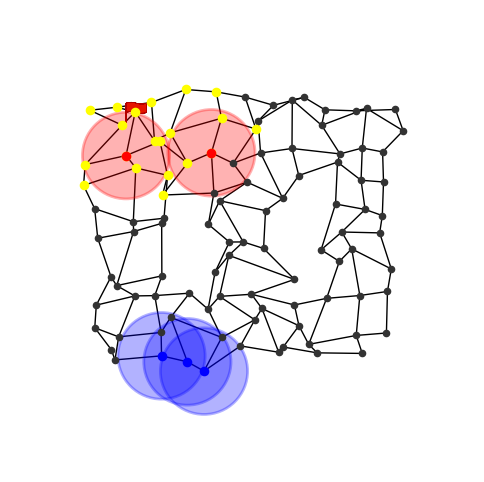

In [ ]:
env_3v2.reset()
env_3v2.render()

pos_dict = nx.get_node_attributes(bc.G, 'pos')
pos = pos_dict[0]
ax.scatter(*pos, color="pink", s=35, zorder=6)